In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import bte


Notebook to visualise MOV clusters with singletons from UShER phylogenies. MOV-like nodes are defined as nodes with LLRs > 3 and sum_contexts > 2.

In [3]:
df = pd.read_csv("/Users/reem/merged_bte_mov_strict.tsv", sep="\t")
df.head()

,Unnamed: 0,node_id,parent_id,children,mutations,num_mutations,LLR,sum_llrs,sum_contexts,country,cluster_size,size_bin,year
0,0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,4.774250,7.027866,2.253616,Tanzania,1.0,1,2021
1,1,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,node_243043,[],"'C8299T', 'C10369T', 'C10714T', 'C12528T', 'C1...",9,3.925618,6.601791,2.676172,India,1.0,1,2020
2,2,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,node_243370,[],"'C676T', 'C1387T', 'C5986T', 'G8990A', 'C9487T...",10,3.672689,6.405349,2.732660,Mexico,1.0,1,2020
3,3,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,node_254525,[],"'C2110T', 'C6954T', 'T7984C', 'C8809T', 'C8890...",10,3.465710,5.982177,2.516467,USA,1.0,1,2021
4,4,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,node_543775,[],"'G428A', 'G1156A', 'C1282T', 'G1358A', 'T1792C...",61,9.789147,21.424638,11.635491,NaN,1.0,1,2022


In [4]:
tree = bte.MATree(pb_file="/Users/reem/2026_updated_tree.pb")


Finished 'from_pb' in 468.0948 seconds


In [20]:
# Plot Mov Clusters

bins = [1,2,4,8,16,32]
labels = ["1","2-3","4-7","8-15","16-30"]

df["size_bin"] = pd.cut(df["cluster_size"], bins=bins, right=False, labels=labels)

dist = df.groupby("size_bin").size().reset_index(name="n_clusters")

fig = px.bar(dist, x="size_bin", y="n_clusters", text="n_clusters", orientation="v")
fig.update_layout(
    xaxis_title="Number of MOV clusters",
    yaxis_title="MOV cluster size (log scale)",
    title="Distribution of MOV clusters vs Number of Descendants"
)
fig.update_traces(width=0.8, textposition="outside") 
fig.update_yaxes(type="log")
fig.show()


/var/folders/bt/jpy5j9ms7pb6p6hhqzvpjffw0000gn/T/ipykernel_52551/3761621930.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [21]:
# save as svg
fig.write_image("/Users/reem/new_figs/distribution_of_mov_clusters.svg")

In [22]:
# Plot MOV clusters per country, collapse singletons into "Other"

country_counts = df["country"].str.strip().value_counts().reset_index()
country_counts.columns = ["country", "n_clusters"]

# Excluding singletons from the plot, but keeping them in the dataframe for accurate counts
# country_counts = country_counts[country_counts["n_clusters"] >2]
country_counts.loc[country_counts["n_clusters"] <= 2, "country"] = "Other"
# country_counts = country_counts.groupby("country")["n_clusters"].sum().reset_index()
            
fig = px.bar(
    country_counts.sort_values(by="n_clusters", ascending=True),
    x="n_clusters", y="country",
    orientation="h",
    title="Number of MOV clusters per country"
)
fig.update_layout(xaxis_title="Number of MOV clusters", yaxis_title="Country", height=1000)
fig.show()



In [23]:
fig.write_image("/Users/reem/new_figs/distribution_of_mov_per_country.svg")

In [81]:
meta = pd.read_csv("/Users/reem/metafitch_date_output.tsv", sep="\t")


/var/folders/bt/jpy5j9ms7pb6p6hhqzvpjffw0000gn/T/ipykernel_52551/1652612753.py:1: DtypeWarning:

Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.



In [90]:
df = df.merge(meta[["strain", "date"]], left_on= "node_id", right_on="strain", how="left")
df.head(10)

,Unnamed: 0,node_id,parent_id,children,mutations,num_mutations,LLR,sum_llrs,sum_contexts,country,year,cluster_size,size_bin,strain_x,year,strain_y,date
0,0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,4.774250,7.027866,2.253616,Tanzania,NaN,1.0,1,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,NaN,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,2021
1,1,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,node_243043,[],"'C8299T', 'C10369T', 'C10714T', 'C12528T', 'C1...",9,3.925618,6.601791,2.676172,India,NaN,1.0,1,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,NaN,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,2020
2,2,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,node_243370,[],"'C676T', 'C1387T', 'C5986T', 'G8990A', 'C9487T...",10,3.672689,6.405349,2.732660,Mexico,NaN,1.0,1,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,NaN,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,2020
3,3,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,node_254525,[],"'C2110T', 'C6954T', 'T7984C', 'C8809T', 'C8890...",10,3.465710,5.982177,2.516467,USA,NaN,1.0,1,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,NaN,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,2021
4,4,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,node_543775,[],"'G428A', 'G1156A', 'C1282T', 'G1358A', 'T1792C...",61,9.789147,21.424638,11.635491,NaN,NaN,1.0,1,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,NaN,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,2022.0
5,5,node_546047,node_546046,"['node_546048', 'England/NORT-YNBS1NA/2022|EPI...","'G425A', 'C619T', 'G2076A', 'G3089A', 'T3595C'...",31,6.258186,16.999543,10.741357,England,NaN,4.0,4-7,node_546047,NaN,node_546047,2022.0
6,6,hCoV-19/USA/MN-CDC-IBX024513492461/2022|2022-0...,node_558046,[],"'G428A', 'G644A', 'G1709A', 'G3729A', 'C3736T'...",28,7.760148,14.197639,6.437491,NaN,NaN,1.0,1,hCoV-19/USA/MN-CDC-IBX024513492461/2022|2022-0...,NaN,hCoV-19/USA/MN-CDC-IBX024513492461/2022|2022-0...,2022.0
7,7,Denmark/DCGC-369053/2022|EPI_ISL_10012883|2022...,node_568664,[],"'C2416T', 'A4851G', 'C5052T', 'G5387A', 'C1139...",12,4.285868,6.997273,2.711405,Denmark,NaN,1.0,1,Denmark/DCGC-369053/2022|EPI_ISL_10012883|2022...,NaN,Denmark/DCGC-369053/2022|EPI_ISL_10012883|2022...,2022.0
8,8,Denmark/DCGC-651260/2022|EPI_ISL_18152107|2022...,node_569251,[],"'A963G', 'G4444A', 'C6539T', 'T6964C', 'T8830C...",20,3.544327,8.043300,4.498973,Denmark,NaN,1.0,1,Denmark/DCGC-651260/2022|EPI_ISL_18152107|2022...,NaN,Denmark/DCGC-651260/2022|EPI_ISL_18152107|2022...,2022.0
9,9,Australia/VIC46621/2022|EPI_ISL_11630027|2022-...,node_573957,[],"'G9383A', 'A10918G', 'C15388T', 'C17421T', 'G1...",11,3.203061,6.020856,2.817795,Australia,NaN,1.0,1,Australia/VIC46621/2022|EPI_ISL_11630027|2022-...,NaN,Australia/VIC46621/2022|EPI_ISL_11630027|2022-...,2022.0


In [91]:
df.drop(columns=["strain_x","strain_y","year"], inplace=True)
df.head()

,Unnamed: 0,node_id,parent_id,children,mutations,num_mutations,LLR,sum_llrs,sum_contexts,country,cluster_size,size_bin,date
0,0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,4.774250,7.027866,2.253616,Tanzania,1.0,1,2021
1,1,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,node_243043,[],"'C8299T', 'C10369T', 'C10714T', 'C12528T', 'C1...",9,3.925618,6.601791,2.676172,India,1.0,1,2020
2,2,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,node_243370,[],"'C676T', 'C1387T', 'C5986T', 'G8990A', 'C9487T...",10,3.672689,6.405349,2.732660,Mexico,1.0,1,2020
3,3,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,node_254525,[],"'C2110T', 'C6954T', 'T7984C', 'C8809T', 'C8890...",10,3.465710,5.982177,2.516467,USA,1.0,1,2021
4,4,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,node_543775,[],"'G428A', 'G1156A', 'C1282T', 'G1358A', 'T1792C...",61,9.789147,21.424638,11.635491,NaN,1.0,1,2022.0


In [92]:
df.rename(columns={"date": "year"}, inplace=True)

In [94]:
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df.head()

,Unnamed: 0,node_id,parent_id,children,mutations,num_mutations,LLR,sum_llrs,sum_contexts,country,cluster_size,size_bin,year
0,0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,4.774250,7.027866,2.253616,Tanzania,1.0,1,2021
1,1,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,node_243043,[],"'C8299T', 'C10369T', 'C10714T', 'C12528T', 'C1...",9,3.925618,6.601791,2.676172,India,1.0,1,2020
2,2,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,node_243370,[],"'C676T', 'C1387T', 'C5986T', 'G8990A', 'C9487T...",10,3.672689,6.405349,2.732660,Mexico,1.0,1,2020
3,3,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,node_254525,[],"'C2110T', 'C6954T', 'T7984C', 'C8809T', 'C8890...",10,3.465710,5.982177,2.516467,USA,1.0,1,2021
4,4,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,node_543775,[],"'G428A', 'G1156A', 'C1282T', 'G1358A', 'T1792C...",61,9.789147,21.424638,11.635491,NaN,1.0,1,2022


In [97]:
df.to_csv("/Users/reem/merged_bte_mov_strict.tsv", sep="\t", index=False)

In [122]:
year_counts = df["year"].value_counts().reset_index()
year_counts.columns = ["year", "num_mov_clusters"]
year_counts.sort_values(by="year")
fig = px.bar(
    year_counts.sort_values(by="year"),
    x="year", y="num_mov_clusters",
    title="Number of MOV clusters per year",
    color_discrete_sequence=["indianred"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Number of MOV clusters")
fig.show()

In [123]:
fig.write_image("/Users/reem/new_figs/mov_clusters_per_year.svg")

In [104]:
import tqdm
iterator = pd.read_csv("/Users/reem/gisaidAndPublic.2026-01-26.gisaidNames.metadata.tsv.gz", sep="\t", chunksize=10000)
metadata = pd.concat([chunk for chunk in tqdm.tqdm(iterator)], ignore_index=True)
print(len(metadata))
print(metadata.head())

1725it [00:19, 89.72it/s] 


17245272
                                              strain genbank_accession  \
0                    186951/USA/2023|PX732842.1|2023        PX732842.1   
1  Guangdong/HKU-SZ-002/2020|EPI_ISL_406030|2020-...        MN938384.1   
2  Shenzhen/HKU-SZ-005/2020|EPI_ISL_405839|2020-0...        MN975262.1   
3         Wuhan/WHU01/2020|EPI_ISL_406716|2020-01-02        MN988668.1   
4         Wuhan/WHU02/2020|EPI_ISL_406717|2020-01-02        MN988669.1   

         date country host completeness   length Nextstrain_clade  \
0        2023     USA  NaN          NaN  29649.0    23A (XBB.1.5)   
1  2020-01-10   China  NaN          NaN  29838.0              19B   
2  2020-01-11   China  NaN          NaN  29891.0              19B   
3  2020-01-02   China  NaN          NaN  29881.0              19A   
4  2020-01-02   China  NaN          NaN  29881.0              19A   

  pangolin_lineage Nextstrain_clade_usher pango_lineage_usher  
0          XBB.1.5          23A (XBB.1.5)       XBB.1.5_17124  
1  

In [105]:
metadata["date"] = metadata["date"].replace("?", np.nan)
metadata['Year'] = pd.DatetimeIndex(metadata['date']).year

metadata["Year"].head(20)

0     2023.0
1     2020.0
2     2020.0
3     2020.0
4     2020.0
5        NaN
6        NaN
7        NaN
8     2020.0
9        NaN
10       NaN
11       NaN
12    2022.0
13    2022.0
14    2022.0
15    2022.0
16    2022.0
17    2022.0
18    2022.0
19    2022.0
Name: Year, dtype: float64

In [ ]:
# Get the total number of sequence per year from Gisaid metadata, and save to a tsv
metadata["Year"] = pd.to_numeric(metadata["Year"], errors="coerce").astype("Int64")
metadata["Year"] = metadata["Year"].fillna(0).astype(int) 

#Remove years with very low counts (before 2019)
year_counts = metadata["Year"].value_counts().reset_index()
year_counts.columns = ["year", "count"]
year_counts = year_counts[year_counts["year"] >= 2019]
year_counts.sort_values(by="year", inplace=True)
i = year_counts[year_counts["year"] < 2019].index
year_counts.drop(i, axis=0, inplace=True)

In [ ]:
# Save value counts of years to a csv
year_counts.to_csv("/Users/reem/total_seqs_per_year.tsv",sep="\t", index=False)


In [21]:
year_counts = pd.read_csv("/Users/reem/total_seqs_per_year.tsv", sep="\t")

year_counts

,Year,count
0,2020,814241
1,2021,7341360
2,2022,6743816
3,2023,1549182
4,2024,580755
5,2025,213102
6,2026,1103


In [112]:
# Num Mov clusters per year
mov_counts_per_year = df["year"].value_counts().reset_index()
mov_counts_per_year.columns = ["year", "n_clusters"]
mov_counts_per_year.sort_values(by="year", inplace=True)
mov_counts_per_year

,year,n_clusters
5,2020,2
3,2021,16
0,2022,560
1,2023,329
2,2024,78
4,2025,16


In [113]:
plotly_df = pd.merge(year_counts, mov_counts_per_year, on="year", how="left").fillna(0)
plotly_df

,year,count,n_clusters
0,2019,50,0
1,2020,814241,2
2,2021,7341360,16
3,2022,6743816,560
4,2023,1549182,329
5,2024,580755,78
6,2025,213102,16
7,2026,1103,0


In [115]:
# MOV_Clusters per year Normalized by total sequences per year
plotly_df["mov_normalized"] = (plotly_df["n_clusters"] / plotly_df["count"]) *1e6




fig = px.bar(
    plotly_df.sort_values(by="year"),
    x="year", y="mov_normalized",
    title="Number of MOV clusters normalized by total sequences per year",
    color_discrete_sequence=["indianred"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Number of MOV clusters per million sequences")
fig.show()

In [116]:
fig.write_image("/Users/reem/new_figs/mov_clusters_per_year_normalized.svg")

In [119]:
mov_counts_per_year

,year,n_clusters
5,2020,2
3,2021,16
0,2022,560
1,2023,329
2,2024,78
4,2025,16


In [120]:
# Mov Percentage per year

year_totals = mov_counts_per_year.merge(year_counts, on="year")

year_totals["mov_percentage"] = (year_totals["n_clusters"] / year_totals["count"]) * 100

year_totals


fig = px.bar(
    year_totals.sort_values(by="year"),
    x="year", y="mov_percentage",
    title="Percentage of MOV clusters per year",
    color_discrete_sequence=["purple"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of MOV clusters (%)")
fig.show()


In [121]:
fig.write_image("/Users/reem/new_figs/percent_mov_clusters_per_year.svg")

In [8]:
df = pd.read_csv("/Users/reem/merged_bte_metafitch.tsv", sep="\t")


In [14]:
# Functon to extract proportion of mov_seqs per country per year
def plot_mov_proportion(df, country):
    df_country = df[df["country"] == country]
    total_seqs = df_country["Year"].value_counts().reset_index()
    mov_seqs = df_country[(df_country["LLR"]>3) & (df_country["sum_contexts"]>2)]["Year"].value_counts().reset_index()
    #mov_seqs = df_country[df_country["sum_llrs"]>6]["Year"].value_counts().reset_index()
    merged = total_seqs.merge(mov_seqs, on=total_seqs.columns[0], how="left").fillna(0)
    merged.columns = ["Year", "total_seqs", "mov_seqs"]
    merged["proportion_mov"] = (merged["mov_seqs"] / merged["total_seqs"]) * 100
    merged = merged[merged["Year"] != "0"].astype({"Year": str})

    fig = px.bar(merged.sort_values(by="Year"),
        x="Year", y="proportion_mov",
        title=f"Percentage of MOV sequences per year in {country}",
        color_discrete_sequence=["teal"]
    )
    fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of MOV sequences (%)")
    fig.update_yaxes(range=[0, 0.5])
    fig.show()
    #fig.write_image(f"/Users/reem/{country}_MOV_Proportion_per_Year.svg")
    return merged


#plot_mov_proportion(df, country="Australia")      
plot_mov_proportion(df, country="USA")

,Year,total_seqs,mov_seqs,proportion_mov
0,2021,1262373,10.0,0.000792
1,2022,957229,113.0,0.011805
2,2023,308294,95.0,0.030815
3,2024,170423,20.0,0.011736
4,2020,137610,0.0,0.000000
5,2025,48650,6.0,0.012333
6,0,1274,0.0,0.000000
7,1905,1,0.0,0.000000


In [ ]:
# Same but grouped barplot. France is barely visible
rows = []
Years = [2020, 2021, 2022, 2023, 2024, 2025]
for year in Years:
    df_yr = df[df["Year"]==year]
    Mov_pred = (df_yr["LLR"] > 3) & (df_yr["sum_contexts"] > 2)
    rows.append({
        "Australia_prop": Mov_pred[df_yr["country"]=="Australia"].sum()/len(df_yr[df_yr["country"]=="Australia"])*100,
        "France_prop": Mov_pred[df_yr["country"]=="France"].sum()/len(df_yr[df_yr["country"]=="France"])*100,
        "year": year,
    })
plotly_df = pd.DataFrame(rows)  

fig = px.bar(plotly_df, x="year", y=["Australia_prop", "France_prop"],
             barmode = 'group')
fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of MOV sequences")


fig.show() 
fig.write_image("/Users/reem/mov_proportion_aus_france.svg")                         

In [152]:
plotly_df

,Australia_prop,France_prop,year
0,0.000000,0.000000,2020
1,0.000000,0.000000,2021
2,0.290991,0.000673,2022
3,0.445337,0.005009,2023
4,0.203626,0.000000,2024
5,0.074446,0.000000,2025


In [48]:
df_mov = pd.read_csv("/Users/reem/Desktop/Documents/all_mov_bte_final.tsv", sep="\t")
df_mov.head()

,node_id,Children,Mutations,Cluster size,LLR,sum_contexts,sum_llrs,country,Year
0,node_1793301,"['node_1793302', 'Australia/NSW-SAVID-9682/202...","['C2595T', 'T3607C', 'C4464T', 'C6525T', 'G909...",20,5.983130,7.843964,13.827095,Australia,2022
1,node_2172435,"['node_2172436', 'Australia/ACT10023/2022|EPI_...","['G509A', 'G611A', 'A1802G', 'G1868A', 'C2881T...",14,4.446203,2.826779,7.272982,Australia,2022
2,node_2176874,['NewZealand/23YA0642/2023|EPI_ISL_16953828|20...,"['G1212A', 'C3634T', 'G5326A', 'C5893T', 'G105...",13,3.625232,5.083141,8.708374,New Zealand,2023
3,node_1472129,"['node_1472130', 'Australia/ACT8719/2022|EPI_I...","['G816A', 'A895G', 'G1325A', 'C1454T', 'C1549T...",9,13.332206,3.851261,17.183468,Australia,2022
4,node_2487450,"['node_2487451', 'node_2487454']","['C884T', 'G1462A', 'G1823A', 'G5180A', 'G5612...",9,6.060567,3.175023,9.235590,USA,2025


In [62]:
df_plot = df_mov[["Year","Cluster size"]].value_counts().reset_index()
df_plot.columns = ["Year", "Cluster size", "n_clusters"]
df_plot.sort_values(by="Year", inplace=True)
df_plot

,Year,Cluster size,n_clusters
14,2020,1,2
24,2021,5,1
6,2021,1,13
16,2021,2,2
0,2022,1,445
23,2022,8,1
3,2022,2,59
5,2022,4,14
7,2022,3,13
20,2022,9,1


<Axes: xlabel='Year', ylabel='Cluster size'>

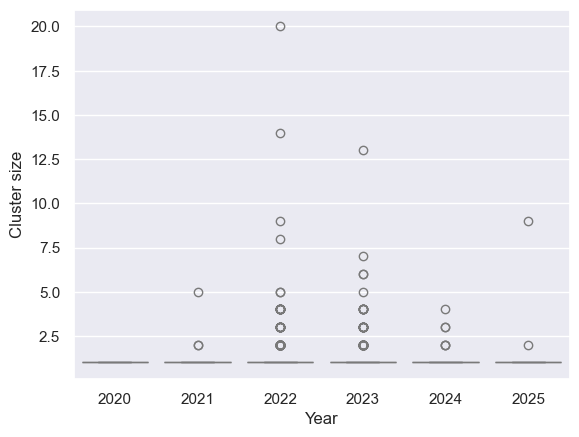

In [127]:


sns.boxplot(
    data=df_mov,
    x="Year",
    y="Cluster size",
    
     color="lightblue"
)

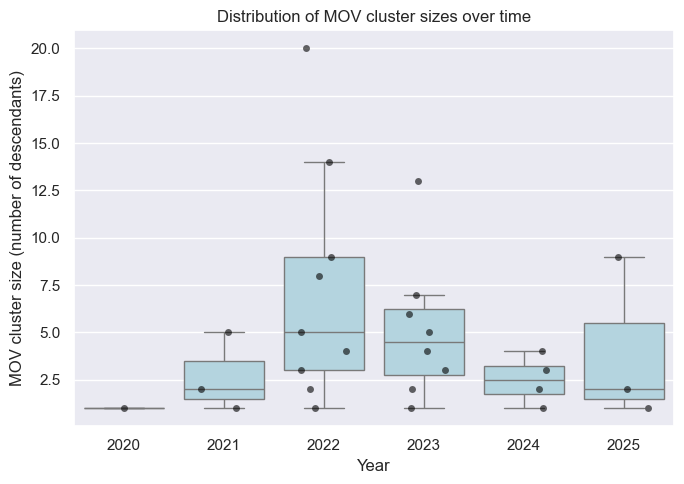

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.set_theme(style="darkgrid")
sns.boxplot(
    data=df_plot,
    x="Year",
    y="Cluster size",
    showfliers=False,
     color="lightblue"
)

sns.stripplot(
    data=df_plot,
    x="Year",
    y="Cluster size",
    color="black",
    alpha=0.6,
    jitter=0.25,
    size=5
)

plt.ylabel("MOV cluster size (number of descendants)")
plt.xlabel("Year")
plt.title("Distribution of MOV cluster sizes over time")

plt.tight_layout()
plt.show()





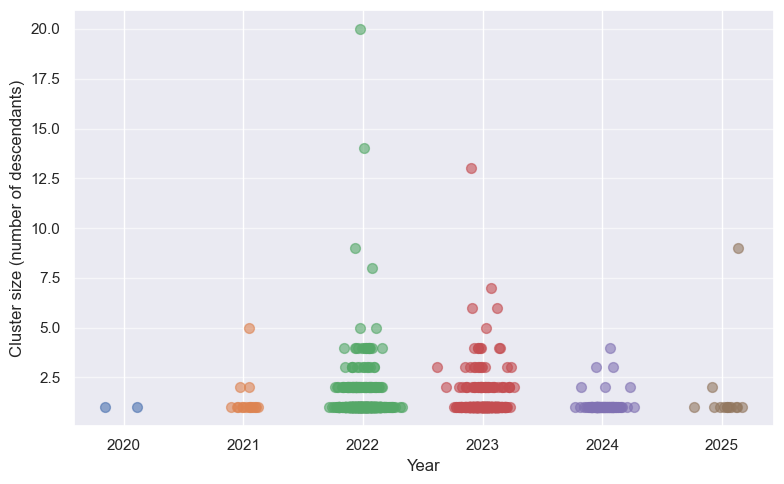

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

# Expand data: create one row per count
rows = []
for _, row in df_plot.iterrows():
    for i in range(row['n_clusters']):
        rows.append({'Year': row['Year'], 'Cluster size': row['Cluster size']})
        
df_expanded = pd.DataFrame(rows)

# Plot
plt.figure(figsize=(8, 5))
for year in df_expanded['Year'].unique():
    data = df_expanded[df_expanded['Year'] == year]
    x = data['Year'] + np.random.normal(0, 0.1, len(data))
    y = data['Cluster size'] 
    plt.scatter(x, y, alpha=0.6, s=50)
 

plt.xlabel('Year')
plt.ylabel('Cluster size (number of descendants)')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

